# QuickBite Express — Crisis Impact & Recovery: Stakeholder Report

**Prepared by:** Khizar Abbas Khan | **Date:** 2025 | **Data Period:** Jan–Sep 2025

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                      'axes.titleweight': 'bold', 'axes.titlesize': 14})
G = '#2ecc71'; R = '#e74c3c'; B = '#3498db'; O = '#f39c12'

def load(t):
    return pd.read_csv(f'rpc_18_inputs_for_participants//rpc_18_inputs_for_participants//RPC_18_Datasets//{t}.csv')

orders = load('fact_orders')
ratings = load('fact_ratings')
delivery = load('fact_delivery_performance_enhanced')
for df in [delivery]: [df.drop(columns=[c], inplace=True) for c in df.columns if 'Unnamed' in c]
restaurant = load('restaurant_corrected')
for df in [restaurant]: [df.drop(columns=[c], inplace=True) for c in df.columns if 'Unnamed' in c]
customers = load('dim_customer')

orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'])
orders['month'] = orders['order_timestamp'].dt.to_period('M')
orders['month_num'] = orders['order_timestamp'].dt.month
orders['is_cancelled_flag'] = orders['is_cancelled'].map({'Y':1,'N':0})
orders['period'] = orders['month_num'].apply(lambda m: 'Pre-Crisis' if m<=5 else 'Crisis')
delivery['delay_mins'] = delivery['actual_delivery_time_mins'] - delivery['expected_delivery_time_mins']
ratings['review_timestamp'] = pd.to_datetime(ratings['review_timestamp'], format='%d-%m-%Y %H:%M')

pre = orders[orders['period']=='Pre-Crisis']
crisis = orders[orders['period']=='Crisis']
success = orders[orders['is_cancelled_flag']==0]

pre_custs = set(pre['customer_id'].unique())
crisis_custs = set(crisis['customer_id'].unique())
churned_custs = pre_custs - crisis_custs
retained_custs = pre_custs & crisis_custs

print('Data loaded. Orders:', f'{len(orders):,}', '| Restaurants:', f'{len(restaurant):,}', '| Customers:', f'{len(customers):,}')

Data loaded. Orders: 149,166 | Restaurants: 19,995 | Customers: 107,776


## 1. Crisis Timeline — Order Volume & Cancellation Decline

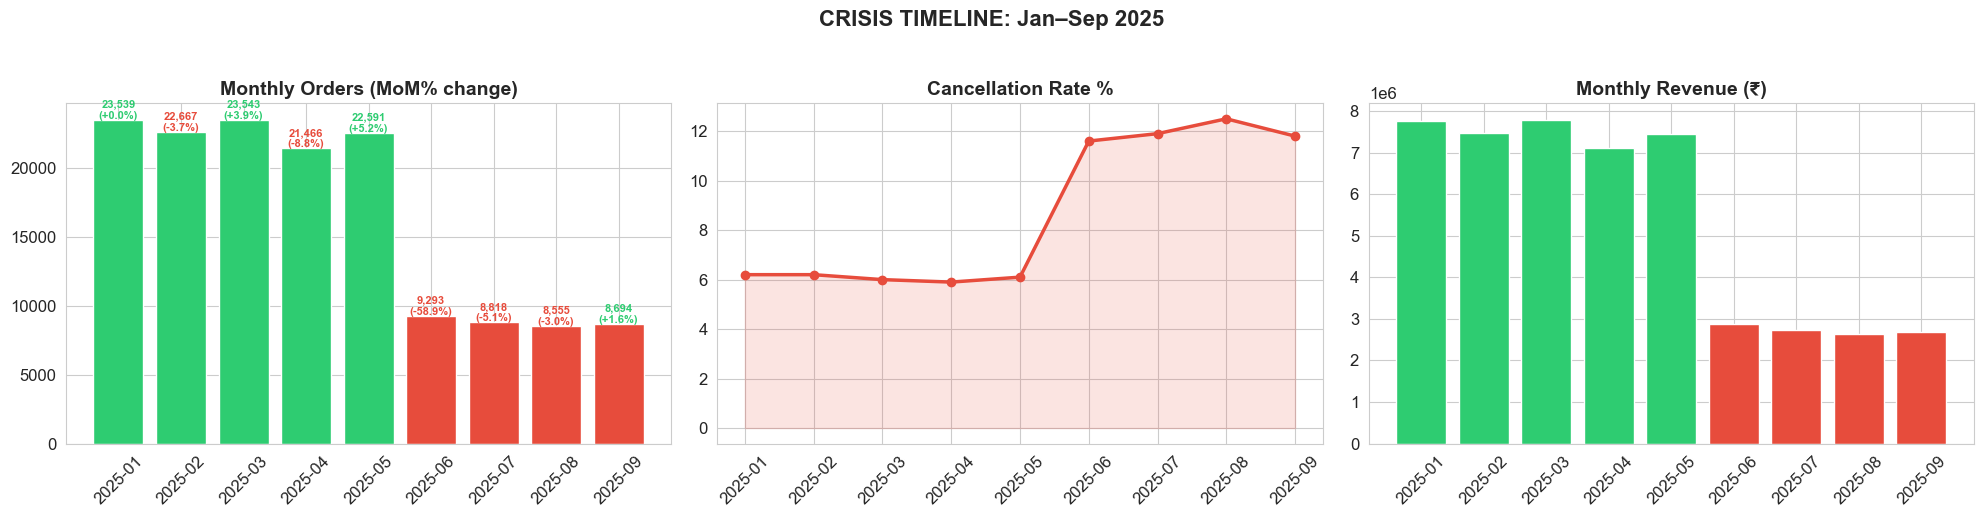

In [2]:
monthly = orders.groupby('month').agg(
    total_orders=('order_id','count'),
    cancelled=('is_cancelled_flag','sum'),
    revenue=('total_amount','sum')
).reset_index()
monthly['cancel_pct'] = (monthly['cancelled']/monthly['total_orders']*100).round(1)
monthly['month_str'] = monthly['month'].astype(str)
monthly['mom_change'] = monthly['total_orders'].pct_change().mul(100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Orders
colors = [G if i<5 else R for i in range(len(monthly))]
bars = axes[0].bar(monthly['month_str'], monthly['total_orders'], color=colors, edgecolor='white')
for bar, val, chg in zip(bars, monthly['total_orders'], monthly['mom_change'].fillna(0)):
    color = G if chg >= 0 else R
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}\n({chg:+.1f}%)', ha='center', fontsize=8, color=color, fontweight='bold')
axes[0].set_title('Monthly Orders (MoM% change)')
axes[0].tick_params(axis='x', rotation=45)

# Cancellation rate
axes[1].plot(monthly['month_str'], monthly['cancel_pct'], marker='o', color=R, linewidth=2.5)
axes[1].fill_between(range(len(monthly)), monthly['cancel_pct'], alpha=0.15, color=R)
axes[1].set_title('Cancellation Rate %')
axes[1].tick_params(axis='x', rotation=45)

# Revenue
bars = axes[2].bar(monthly['month_str'], monthly['revenue'], color=colors, edgecolor='white')
axes[2].set_title('Monthly Revenue (₹)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('CRISIS TIMELINE: Jan–Sep 2025', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 2. Financial Loss Quantification

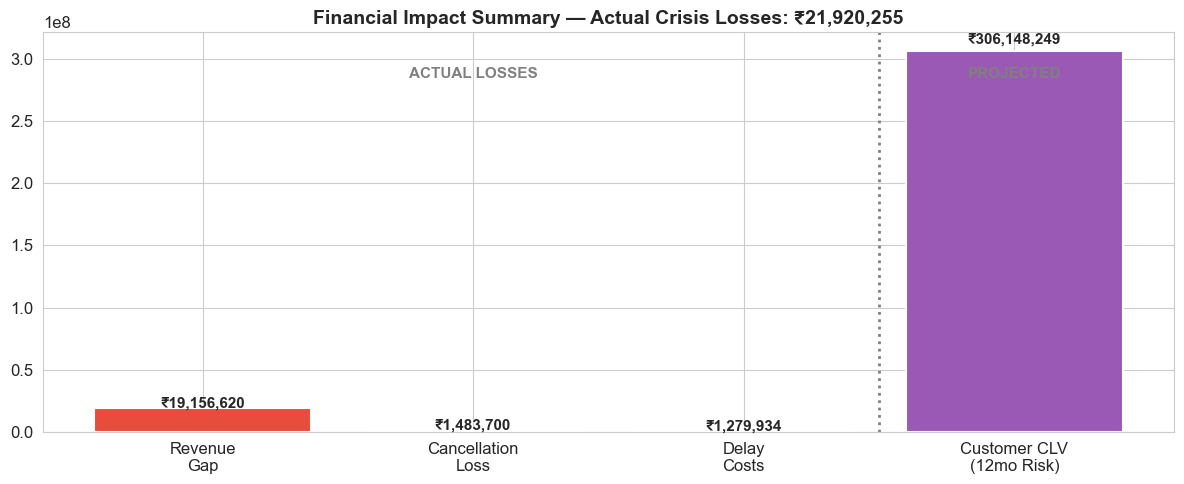

In [3]:
# Revenue gap
pre_avg_rev = success[success['period']=='Pre-Crisis'].groupby('month')['total_amount'].sum().mean()
crisis_monthly_rev = success[success['period']=='Crisis'].groupby('month')['total_amount'].sum()
revenue_gap = sum(max(0, pre_avg_rev - v) for v in crisis_monthly_rev)

# Cancellation loss
avg_order_val = success['total_amount'].mean()
crisis_cancels = crisis['is_cancelled_flag'].sum()
cancel_loss = crisis_cancels * avg_order_val

# Delivery cost
del_crisis = delivery.merge(crisis[['order_id']], on='order_id')
delay_cost = del_crisis[del_crisis['delay_mins']>0]['delay_mins'].sum() * 2  # ₹2/min

# Customer CLV at risk
churned_data = orders[orders['customer_id'].isin(churned_custs)].groupby('customer_id').agg(
    spent=('total_amount','sum'), months=('month','nunique')).reset_index()
churned_data['clv_12mo'] = (churned_data['spent']/churned_data['months'])*12
clv_risk = churned_data['clv_12mo'].sum()

actual = revenue_gap + cancel_loss + delay_cost

fig, ax = plt.subplots(figsize=(12, 5))
labels = ['Revenue\nGap', 'Cancellation\nLoss', 'Delay\nCosts', 'Customer CLV\n(12mo Risk)']
vals = [revenue_gap, cancel_loss, delay_cost, clv_risk]
cols = [R, O, '#e67e22', '#9b59b6']
bars = ax.bar(labels, vals, color=cols, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=11)
ax.axvline(2.5, color='gray', linestyle=':', linewidth=2)
ax.text(1, max(vals)*0.93, 'ACTUAL LOSSES', ha='center', fontsize=11, color='gray', fontweight='bold')
ax.text(3, max(vals)*0.93, 'PROJECTED', ha='center', fontsize=11, color='gray', fontweight='bold')
ax.set_title(f'Financial Impact Summary — Actual Crisis Losses: ₹{actual:,.0f}')
plt.tight_layout()
plt.show()

## 3. Delivery Performance — Root Cause of Crisis

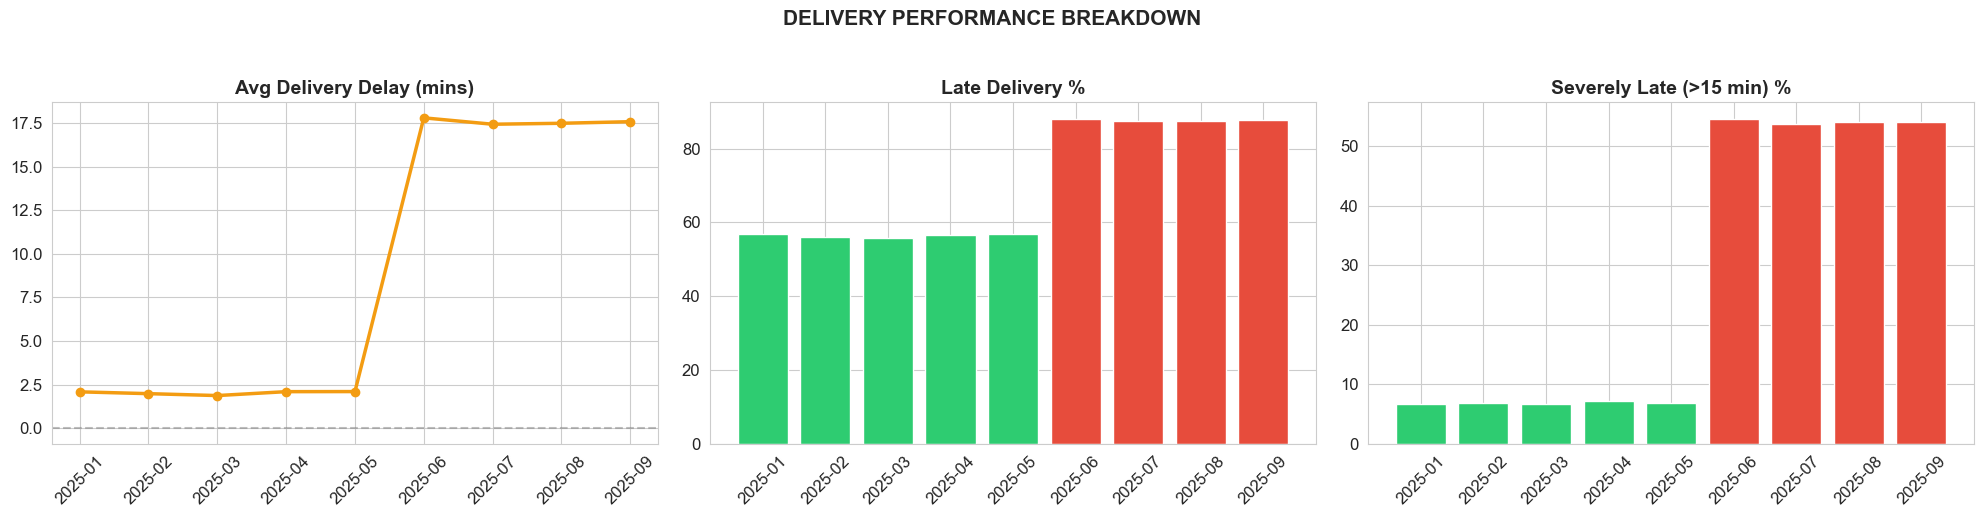

In [4]:
del_with_period = delivery.merge(orders[['order_id','month','period']], on='order_id')

del_monthly = del_with_period.groupby('month').agg(
    avg_delay=('delay_mins','mean'),
    late_pct=('delay_mins', lambda x: (x>0).mean()*100),
    severe_pct=('delay_mins', lambda x: (x>15).mean()*100)
).reset_index()
del_monthly['month_str'] = del_monthly['month'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(del_monthly['month_str'], del_monthly['avg_delay'], marker='o', color=O, linewidth=2.5)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Avg Delivery Delay (mins)')
axes[0].tick_params(axis='x', rotation=45)

colors = [G if i<5 else R for i in range(len(del_monthly))]
axes[1].bar(del_monthly['month_str'], del_monthly['late_pct'], color=colors, edgecolor='white')
axes[1].set_title('Late Delivery %')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(del_monthly['month_str'], del_monthly['severe_pct'], color=colors, edgecolor='white')
axes[2].set_title('Severely Late (>15 min) %')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('DELIVERY PERFORMANCE BREAKDOWN', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 4. Customer Impact — Churn Analysis

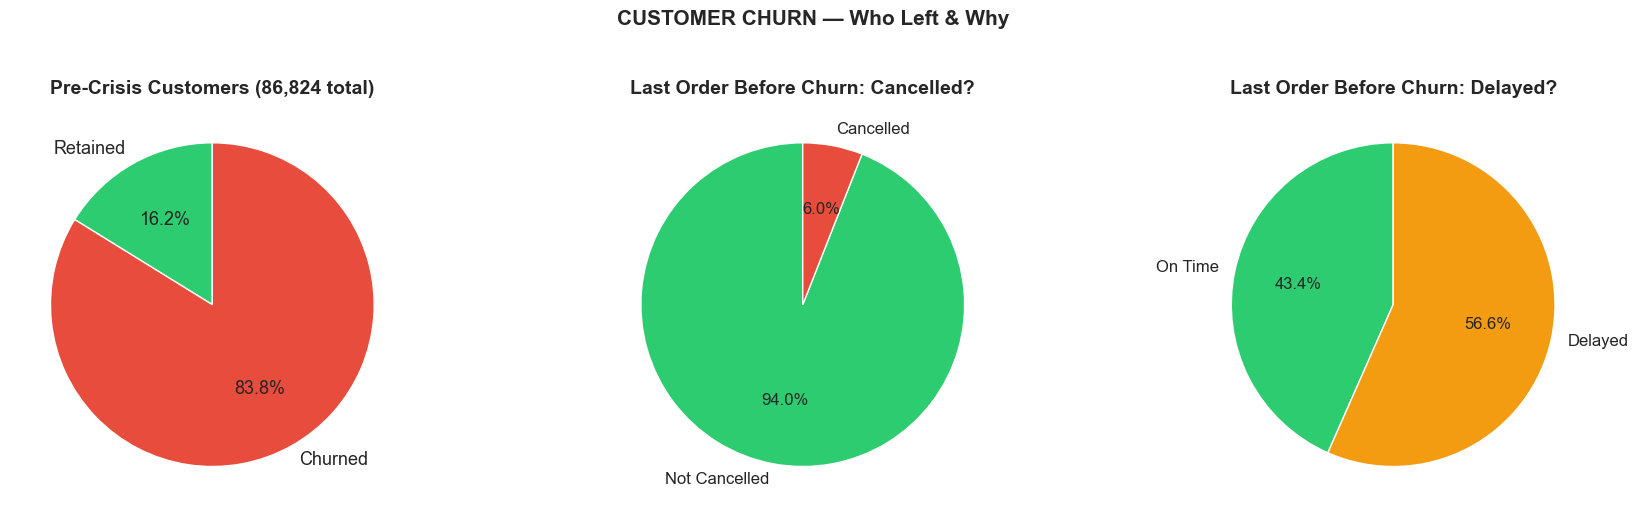

Customer Churn Rate: 83.8% of pre-crisis customers stopped ordering


In [5]:
# Churn summary
churn_rate = len(churned_custs)/len(pre_custs)*100

# Last order analysis
churned_last = orders[orders['customer_id'].isin(churned_custs)].sort_values('order_timestamp').groupby('customer_id').tail(1)
last_merged = churned_last.merge(delivery[['order_id','actual_delivery_time_mins','expected_delivery_time_mins']], on='order_id', how='left')
last_merged['was_delayed'] = (last_merged['actual_delivery_time_mins']>last_merged['expected_delivery_time_mins']).fillna(False).astype(int)
cancelled_pct = churned_last['is_cancelled_flag'].mean()*100
delayed_pct = last_merged['was_delayed'].mean()*100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn pie
axes[0].pie([len(retained_custs), len(churned_custs)], labels=['Retained','Churned'],
            colors=[G, R], autopct='%1.1f%%', startangle=90, textprops={'fontsize':13})
axes[0].set_title(f'Pre-Crisis Customers ({len(pre_custs):,} total)')

# Last order: cancelled?
axes[1].pie([100-cancelled_pct, cancelled_pct], labels=['Not Cancelled','Cancelled'],
            colors=[G, R], autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
axes[1].set_title('Last Order Before Churn: Cancelled?')

# Last order: delayed?
axes[2].pie([100-delayed_pct, delayed_pct], labels=['On Time','Delayed'],
            colors=[G, O], autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
axes[2].set_title('Last Order Before Churn: Delayed?')

plt.suptitle('CUSTOMER CHURN — Who Left & Why', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'Customer Churn Rate: {churn_rate:.1f}% of pre-crisis customers stopped ordering')

## 5. Restaurant Impact — Partner Network Damage

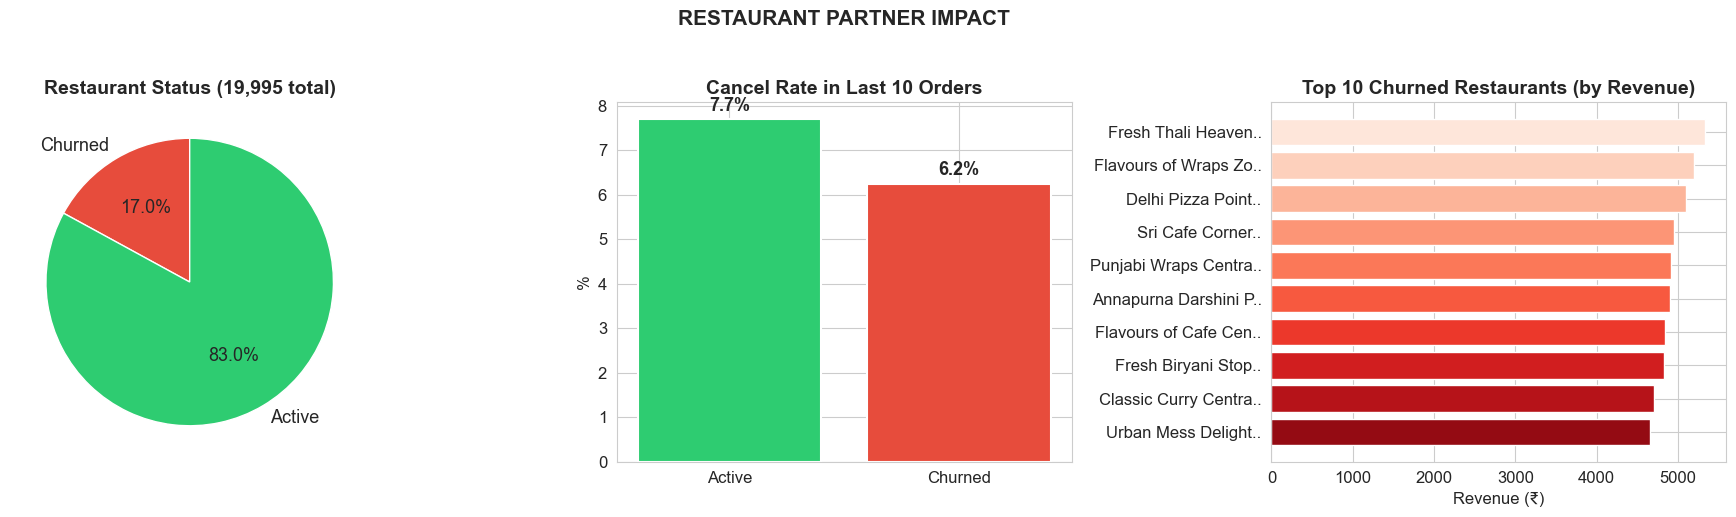

Restaurant churn rate: 17.0% | Revenue from churned: ₹6,387,356


In [6]:
# Churn by type
rest_churn = restaurant.groupby('is_active').size()
rest_churn_rate = (rest_churn.get('N',0)/len(restaurant)*100)

# Cancellation rate: active vs churned (last 10 orders)
rest_orders = restaurant[['restaurant_id','is_active']].merge(orders, on='restaurant_id')
last10 = rest_orders.sort_values(['restaurant_id','order_timestamp'], ascending=False).groupby('restaurant_id').head(10)
cancel_by_status = last10.groupby('is_active')['is_cancelled_flag'].mean()

# Revenue from churned
churned_rest_rev = rest_orders[rest_orders['is_active']=='N']['total_amount'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn split
axes[0].pie(rest_churn.values, labels=['Churned' if k=='N' else 'Active' for k in rest_churn.index],
            colors=[R if k=='N' else G for k in rest_churn.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':13})
axes[0].set_title(f'Restaurant Status ({len(restaurant):,} total)')

# Cancellation comparison
labels_c = ['Active','Churned']
vals_c = [cancel_by_status.get('Y',0)*100, cancel_by_status.get('N',0)*100]
bars = axes[1].bar(labels_c, vals_c, color=[G, R], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals_c):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Cancel Rate in Last 10 Orders')
axes[1].set_ylabel('%')

# Top churned by revenue
top_churned = rest_orders[rest_orders['is_active']=='N'].groupby(['restaurant_id']).agg(
    revenue=('total_amount','sum')).reset_index().merge(
    restaurant[['restaurant_id','restaurant_name','city']], on='restaurant_id'
).sort_values('revenue', ascending=True).tail(10)
axes[2].barh(top_churned['restaurant_name'].str[:20]+'..', top_churned['revenue'],
             color=sns.color_palette('Reds_r', 10), edgecolor='white')
axes[2].set_title('Top 10 Churned Restaurants (by Revenue)')
axes[2].set_xlabel('Revenue (₹)')

plt.suptitle('RESTAURANT PARTNER IMPACT', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'Restaurant churn rate: {rest_churn_rate:.1f}% | Revenue from churned: ₹{churned_rest_rev:,.0f}')

## 6. Geographic Analysis — City-Level Impact

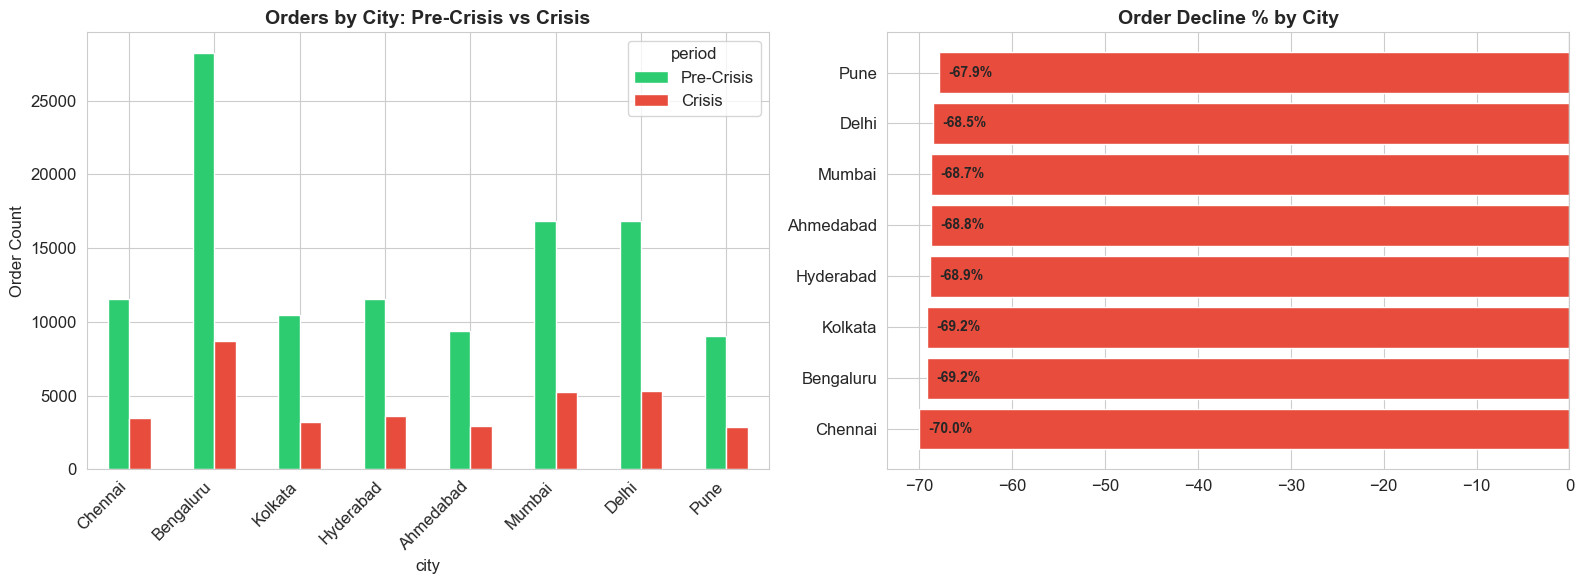

In [7]:
# City-wise order decline
city_orders = orders.merge(restaurant[['restaurant_id','city']], on='restaurant_id')
city_period = city_orders.groupby(['city','period'])['order_id'].count().unstack(fill_value=0)
city_period['Decline %'] = ((city_period['Crisis'] - city_period['Pre-Crisis'])/city_period['Pre-Crisis']*100).round(1)
city_period = city_period.sort_values('Decline %')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

city_period[['Pre-Crisis','Crisis']].plot(kind='bar', ax=axes[0], color=[G, R], edgecolor='white')
axes[0].set_title('Orders by City: Pre-Crisis vs Crisis')
axes[0].set_ylabel('Order Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

bars = axes[1].barh(city_period.index, city_period['Decline %'],
                    color=[R if v<0 else G for v in city_period['Decline %']], edgecolor='white')
for bar, val in zip(bars, city_period['Decline %']):
    axes[1].text(bar.get_width()+(1 if val<0 else -8), bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
axes[1].set_title('Order Decline % by City')
axes[1].axvline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

## 7. Customer Sentiment & Ratings Decline

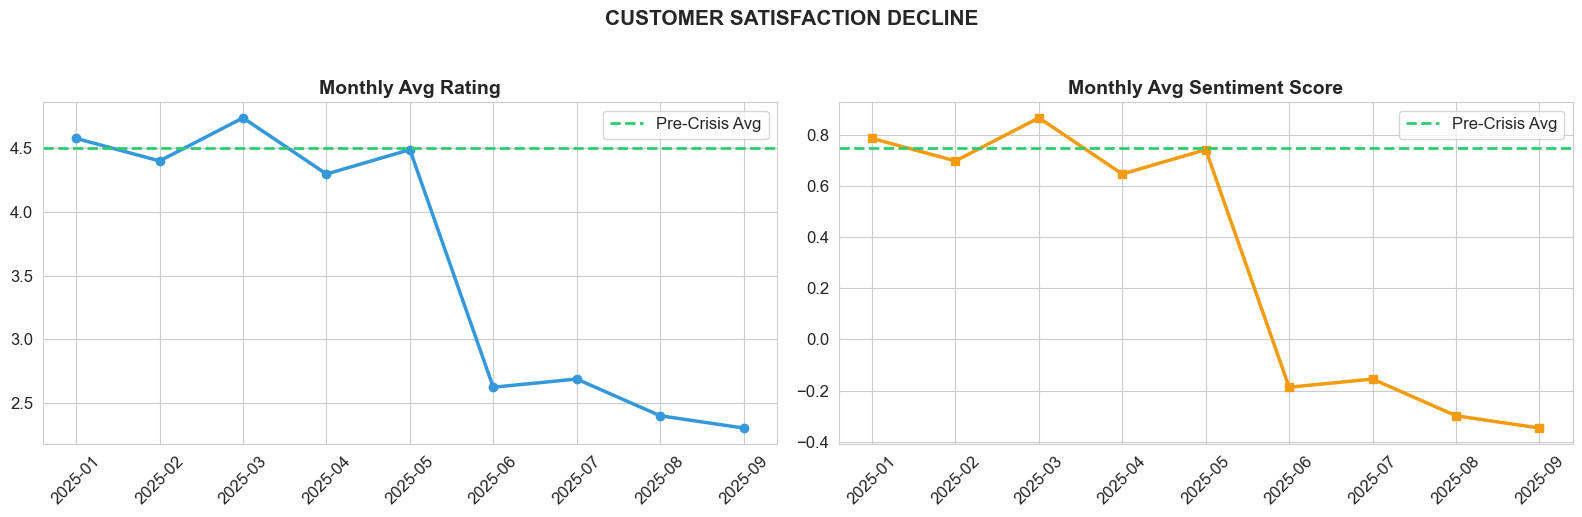

In [8]:
ratings['month'] = ratings['review_timestamp'].dt.to_period('M')
monthly_ratings = ratings.groupby('month').agg(
    avg_rating=('rating','mean'), avg_sentiment=('sentiment_score','mean')
).reset_index()
monthly_ratings['month_str'] = monthly_ratings['month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_ratings['month_str'], monthly_ratings['avg_rating'], marker='o', color=B, linewidth=2.5)
axes[0].axhline(monthly_ratings['avg_rating'].iloc[:5].mean(), color=G, linestyle='--', label='Pre-Crisis Avg', linewidth=2)
axes[0].set_title('Monthly Avg Rating')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_ratings['month_str'], monthly_ratings['avg_sentiment'], marker='s', color=O, linewidth=2.5)
axes[1].axhline(monthly_ratings['avg_sentiment'].iloc[:5].mean(), color=G, linestyle='--', label='Pre-Crisis Avg', linewidth=2)
axes[1].set_title('Monthly Avg Sentiment Score')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('CUSTOMER SATISFACTION DECLINE', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 8. Root Cause Summary

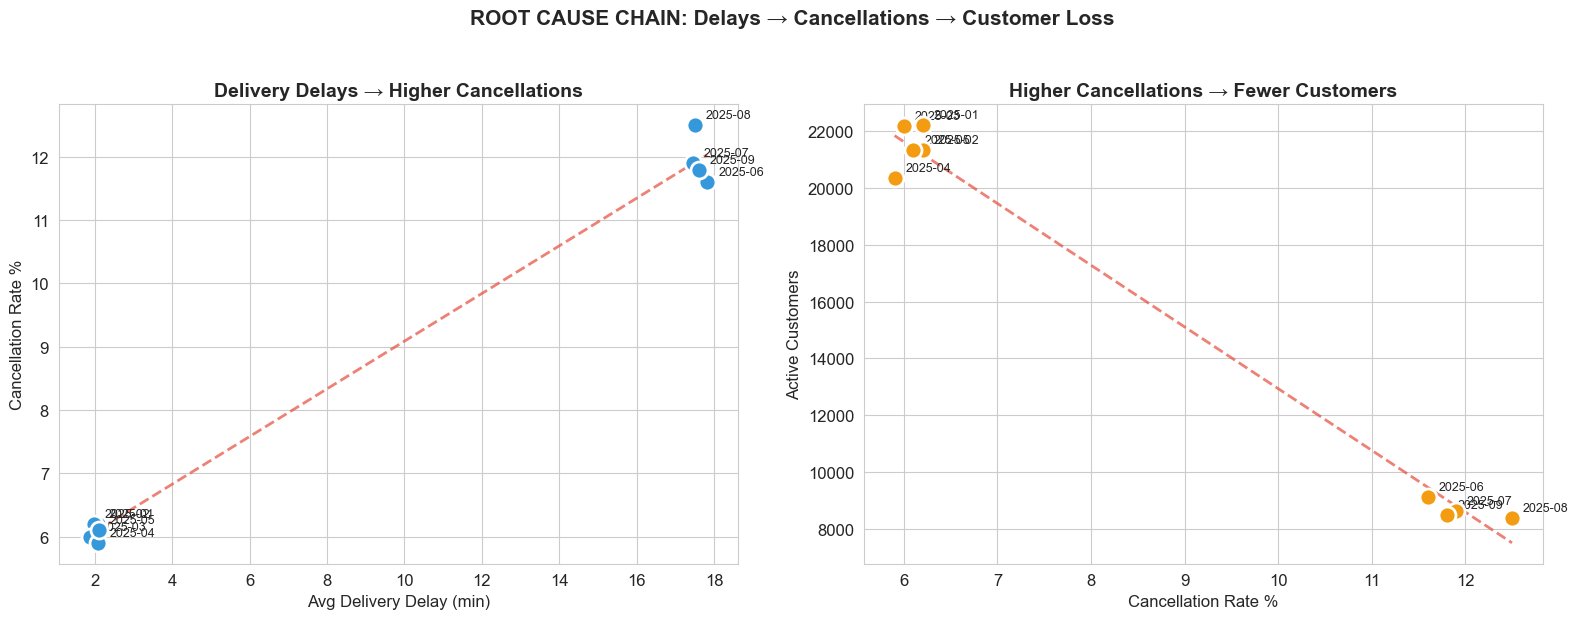

In [9]:
# Correlation: Delivery delay → Cancellations → Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly: delay vs cancel rate
m = monthly.merge(del_monthly[['month','avg_delay']], on='month')
axes[0].scatter(m['avg_delay'], m['cancel_pct'], s=150, c=B, edgecolors='white', linewidth=2, zorder=5)
for _, row in m.iterrows():
    axes[0].annotate(str(row['month']), (row['avg_delay'], row['cancel_pct']),
                     textcoords='offset points', xytext=(8,5), fontsize=9)
z = np.polyfit(m['avg_delay'], m['cancel_pct'], 1)
x_line = np.linspace(m['avg_delay'].min(), m['avg_delay'].max(), 50)
axes[0].plot(x_line, np.polyval(z, x_line), '--', color=R, alpha=0.7, linewidth=2)
axes[0].set_xlabel('Avg Delivery Delay (min)')
axes[0].set_ylabel('Cancellation Rate %')
axes[0].set_title('Delivery Delays → Higher Cancellations')

# Monthly: cancel rate vs customer count
mc = monthly.merge(orders.groupby('month')['customer_id'].nunique().reset_index().rename(
    columns={'customer_id':'active_customers'}), on='month')
axes[1].scatter(mc['cancel_pct'], mc['active_customers'], s=150, c=O, edgecolors='white', linewidth=2, zorder=5)
for _, row in mc.iterrows():
    axes[1].annotate(str(row['month']), (row['cancel_pct'], row['active_customers']),
                     textcoords='offset points', xytext=(8,5), fontsize=9)
z2 = np.polyfit(mc['cancel_pct'], mc['active_customers'], 1)
x_line2 = np.linspace(mc['cancel_pct'].min(), mc['cancel_pct'].max(), 50)
axes[1].plot(x_line2, np.polyval(z2, x_line2), '--', color=R, alpha=0.7, linewidth=2)
axes[1].set_xlabel('Cancellation Rate %')
axes[1].set_ylabel('Active Customers')
axes[1].set_title('Higher Cancellations → Fewer Customers')

plt.suptitle('ROOT CAUSE CHAIN: Delays → Cancellations → Customer Loss', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 9. Recovery Strategy — Prioritized Roadmap

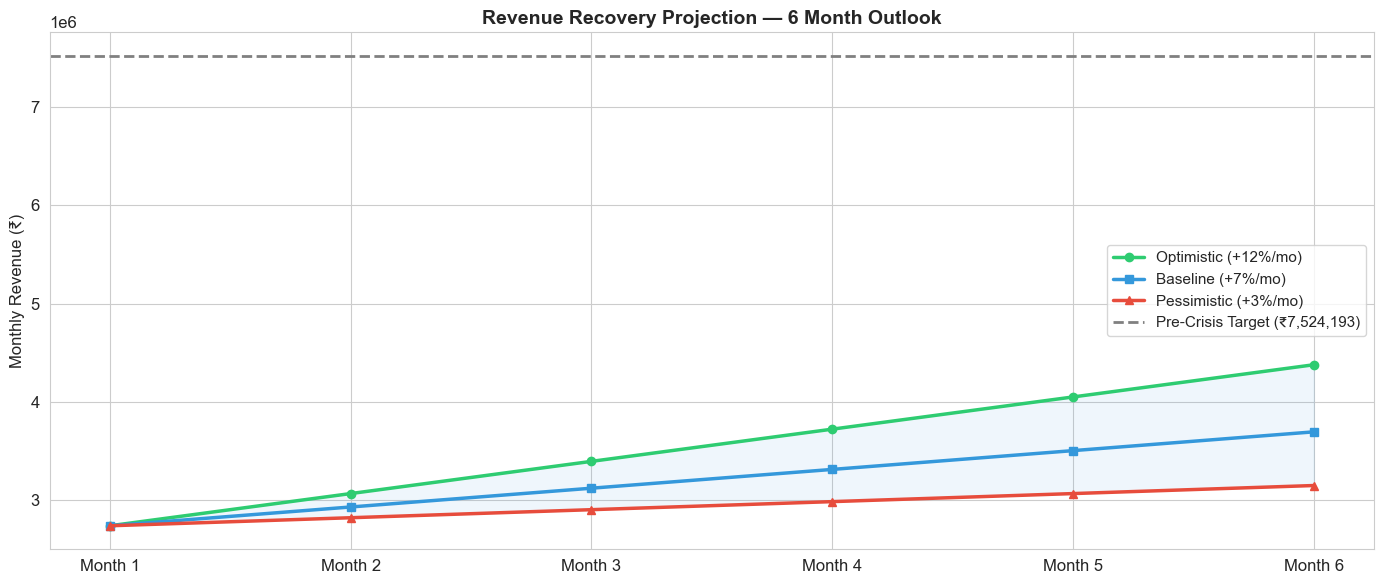

In [10]:
# Recovery scenario projection
pre_rev = pre_avg_rev
crisis_rev = crisis_monthly_rev.mean()

months_lbl = [f'Month {i+1}' for i in range(6)]
pessimistic = [crisis_rev*(1+0.03*i) for i in range(6)]
baseline =    [crisis_rev*(1+0.07*i) for i in range(6)]
optimistic =  [crisis_rev*(1+0.12*i) for i in range(6)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(months_lbl, optimistic, marker='o', linewidth=2.5, color=G, label='Optimistic (+12%/mo)')
ax.plot(months_lbl, baseline, marker='s', linewidth=2.5, color=B, label='Baseline (+7%/mo)')
ax.plot(months_lbl, pessimistic, marker='^', linewidth=2.5, color=R, label='Pessimistic (+3%/mo)')
ax.axhline(pre_rev, color='gray', linestyle='--', linewidth=2, label=f'Pre-Crisis Target (₹{pre_rev:,.0f})')
ax.fill_between(months_lbl, pessimistic, optimistic, alpha=0.08, color=B)
ax.set_title('Revenue Recovery Projection — 6 Month Outlook')
ax.set_ylabel('Monthly Revenue (₹)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10. Recommended Actions

| Week | Priority | Action | Expected Impact |
|------|----------|--------|----------------|
| 1-2 | 🔴 | Fix delivery SLA — surge hire delivery partners | Reduce delays, stop bleeding |
| 1-2 | 🔴 | Halt platform-caused cancellations | Immediate trust restoration |
| 2-4 | 🔴 | Outreach to top 15 churned restaurants with SLA guarantees | Recover highest-revenue partners |
| 2-4 | 🟡 | Launch win-back campaign for Premium churned customers | Highest ROI customer recovery |
| 3-4 | 🟡 | Implement weather-resilient routing & dynamic ETAs | Prevent future monsoon impact |
| 4-8 | 🟢 | Reduced commission for returning restaurants (3 months) | Accelerate partner recovery |
| 4-8 | 🟢 | "We're Back" marketing campaign with real metrics | Rebuild brand confidence |
| 8-12 | 🔵 | Build churn early-warning system (predictive ML) | Prevent future crises |